Loading: bcell.csv
Loading: MHCI.csv
Loading: MHCII.csv

Rows loaded: 28025

Files saved


classification,seq_num,protein,Intended,Redundant Intended,Junction-derived,Linker-only,Novel,junction_burden
0,1,Vaccine1,101,1822,0,0,0,0.0
1,2,Vaccine2,75,1881,0,0,0,0.0
2,3,Vaccine3,62,1577,0,0,0,0.0
3,4,Vaccine4,52,1394,0,0,0,0.0
4,5,Vaccine5,67,1473,0,0,0,0.0
5,6,Vaccine6,68,1504,0,0,0,0.0
6,7,Vaccine7,113,1919,0,0,0,0.0
7,8,Vaccine8,139,1891,0,0,0,0.0
8,9,Vaccine9,77,1847,0,0,0,0.0
9,10,Vaccine10,77,1846,0,0,0,0.0


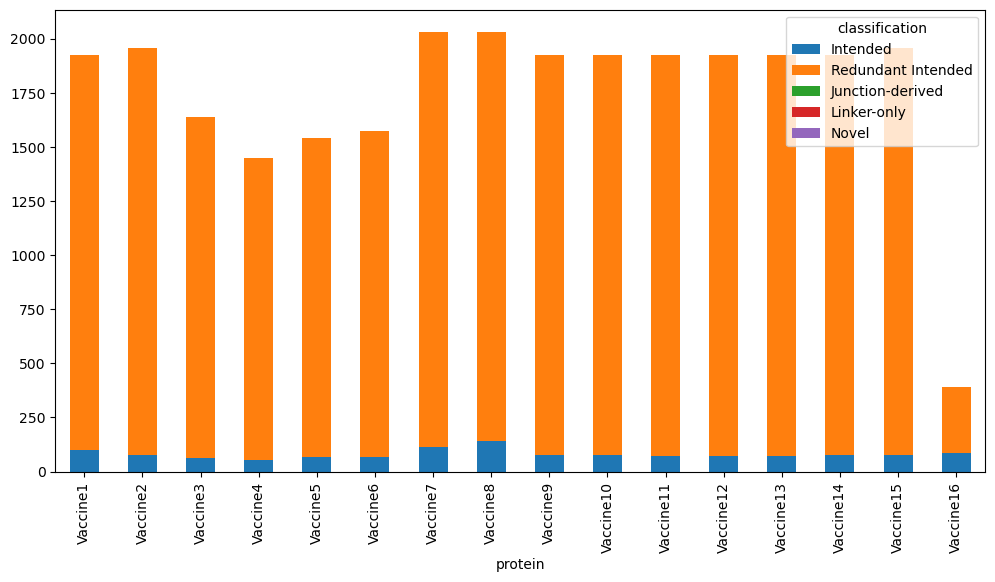

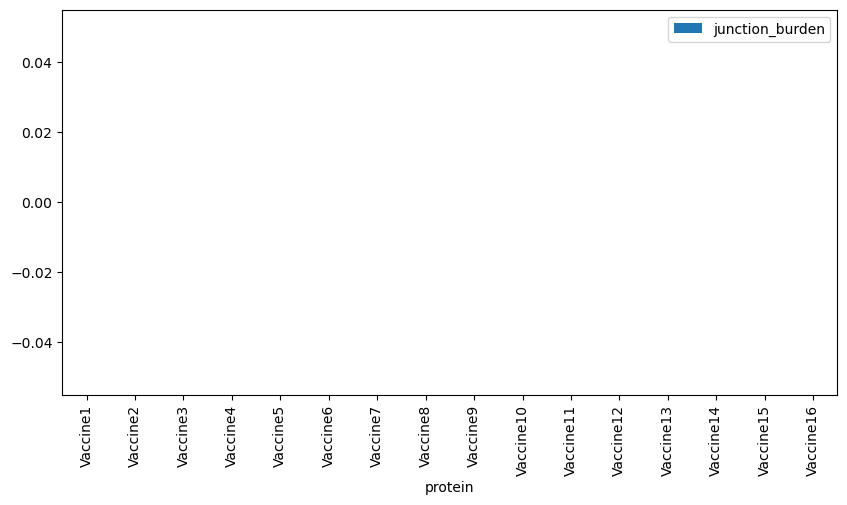

In [7]:
import pandas as pd
import numpy as np
from pathlib import Path
from difflib import SequenceMatcher
import matplotlib.pyplot as plt


SIM_THRESHOLD = 0.70

LINKERS = [
    "GPGPG",
    "EAAAK"
]

SEQ_MAP = {
    1: "Vaccine1",
    2: "Vaccine2",
    3: "Vaccine3",
    4: "Vaccine4",
    5: "Vaccine5",
    6: "Vaccine6",
    7: "Vaccine7",
    8: "Vaccine8",
    9: "Vaccine9",
    10: "Vaccine10",
    11: "Vaccine11",
    12: "Vaccine12",
    13: "Vaccine13",
    14: "Vaccine14",
    15: "Vaccine15",
    16: "Vaccine16"
}


def similarity(a, b):
    return SequenceMatcher(None, str(a), str(b)).ratio()


def detect_linker(peptide):

    peptide = str(peptide)

    found = []

    for l in LINKERS:

        if l in peptide:
            found.append(l)

    if found:
        return ";".join(found)

    return None


def classify(peptide, intended):

    peptide = str(peptide)

    if peptide in intended:
        return "Intended", None

    for x in intended:

        if similarity(peptide, x) >= SIM_THRESHOLD:
            return "Redundant Intended", None

    linker = detect_linker(peptide)

    if linker:

        cleaned = peptide

        for l in LINKERS:
            cleaned = cleaned.replace(l, "")

        if cleaned.strip() == "":
            return "Linker-only", linker

        return "Junction-derived", linker

    return "Novel", None


def load_table(file):

    if str(file).lower().endswith(".tsv"):
        return pd.read_csv(file, sep="\t")

    return pd.read_csv(file)


frames = []

for ext in ["*.csv", "*.tsv"]:

    for file in Path(".").glob(ext):

        fname = file.name.lower()

        if (
            "mhc" not in fname
            and
            "bcell" not in fname
        ):
            continue

        print("Loading:", file.name)

        try:

            df = load_table(file)

        except Exception as e:

            print("Failed:", e)
            continue

        seq_col = None

        for c in df.columns:

            if "seq" in c.lower():
                seq_col = c
                break

        if seq_col is None:
            continue

        if "peptide" not in df.columns:
            continue

        df = df.rename(
            columns={
                seq_col: "seq_num"
            }
        )

        df["source_file"] = file.name

        frames.append(df)


if len(frames) == 0:

    raise Exception(
        "No Bcell / MHCI / MHCII files found."
    )


data = pd.concat(
    frames,
    ignore_index=True
)

print("\nRows loaded:", len(data))


intended = {}

for seq in data["seq_num"].unique():

    subset = data[
        data["seq_num"] == seq
    ]

    selected = []

    for peptide in subset["peptide"]:

        peptide = str(peptide)

        keep = True

        for old in selected:

            if similarity(
                peptide,
                old
            ) >= SIM_THRESHOLD:

                keep = False
                break

        if keep:
            selected.append(peptide)

    intended[seq] = selected


rows = []

for _, row in data.iterrows():

    seq = int(
        row["seq_num"]
    )

    peptide = str(
        row["peptide"]
    )

    cls, linker = classify(
        peptide,
        intended[seq]
    )

    rows.append({

        "seq_num":
            seq,

        "protein":
            SEQ_MAP.get(
                seq,
                "Unknown"
            ),

        "peptide":
            peptide,

        "classification":
            cls,

        "linker":
            linker,

        "source":
            row[
                "source_file"
            ]
    })


detail = pd.DataFrame(
    rows
)

summary = (

    detail

    .groupby(
        [
            "seq_num",
            "protein",
            "classification"
        ]
    )

    .size()

    .unstack(
        fill_value=0
    )

    .reset_index()
)


required = [

    "Intended",

    "Redundant Intended",

    "Junction-derived",

    "Linker-only",

    "Novel"

]

for col in required:

    if col not in summary:
        summary[col] = 0


summary[
    "junction_burden"
] = (

    summary[
        "Junction-derived"
    ]

    /

    (

        summary[
            "Intended"
        ]

        +

        summary[
            "Junction-derived"
        ]

        +

        summary[
            "Novel"
        ]

        +

        1e-9

    )

)


detail.to_csv(
    "junction_detail.csv",
    index=False
)

summary.to_csv(
    "junction_summary.csv",
    index=False
)

print("\nFiles saved")

display(summary)


summary.set_index(
    "protein"
)[required].plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.show()


summary.plot(
    x="protein",
    y="junction_burden",
    kind="bar",
    figsize=(10, 5)
)

plt.show()

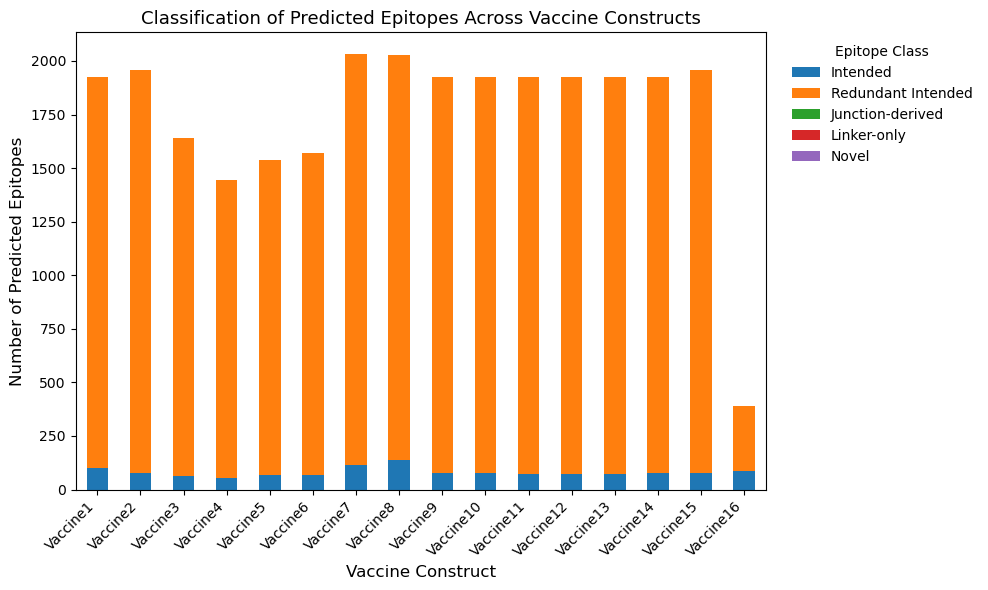

Saved:
 - Figure_Junction_Epitope_Analysis.png
 - Figure_Junction_Epitope_Analysis.tiff


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load summary table
summary = pd.read_csv("junction_summary.csv")

required = [
    "Intended",
    "Redundant Intended",
    "Junction-derived",
    "Linker-only",
    "Novel"
]

# Ensure columns exist
for col in required:
    if col not in summary.columns:
        summary[col] = 0

# Publication-quality figure
fig, ax = plt.subplots(figsize=(10, 6))

summary.set_index("protein")[required].plot(
    kind="bar",
    stacked=True,
    ax=ax
)

ax.set_xlabel("Vaccine Construct", fontsize=12)
ax.set_ylabel("Number of Predicted Epitopes", fontsize=12)
ax.set_title("Classification of Predicted Epitopes Across Vaccine Constructs", fontsize=13)

ax.legend(
    title="Epitope Class",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

# Save publication-quality files
plt.savefig(
    "Figure_Junction_Epitope_Analysis.png",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "Figure_Junction_Epitope_Analysis.tiff",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(" - Figure_Junction_Epitope_Analysis.png")
print(" - Figure_Junction_Epitope_Analysis.tiff")

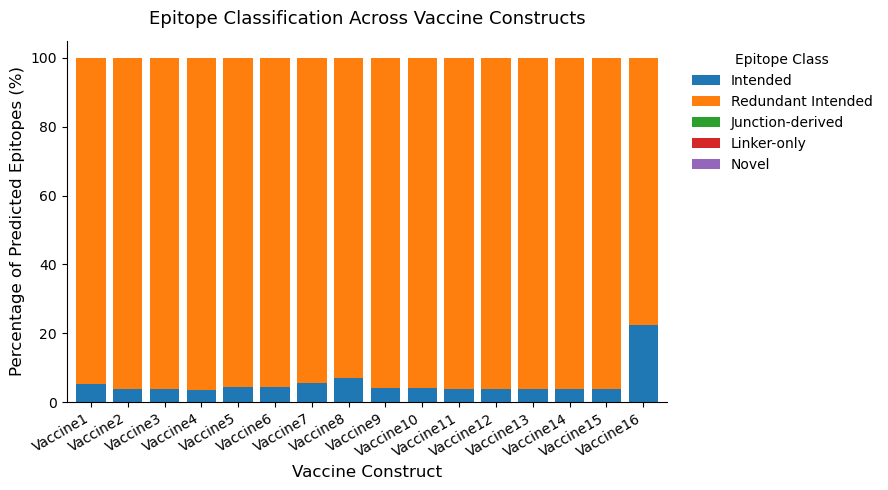

Saved:
Supplementary_Figure_Junction_Epitopes.png
Supplementary_Figure_Junction_Epitopes.tiff


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load results
summary = pd.read_csv("junction_summary.csv")

classes = [
    "Intended",
    "Redundant Intended",
    "Junction-derived",
    "Linker-only",
    "Novel"
]

# Ensure all columns exist
for c in classes:
    if c not in summary.columns:
        summary[c] = 0

# Convert counts to percentages
plot_df = summary.copy()

totals = plot_df[classes].sum(axis=1)

for c in classes:
    plot_df[c] = (
        plot_df[c] / totals * 100
    )

# Create figure
fig, ax = plt.subplots(figsize=(9, 5))

plot_df.set_index("protein")[classes].plot(
    kind="bar",
    stacked=True,
    ax=ax,
    width=0.8
)

# Publication formatting
ax.set_ylabel("Percentage of Predicted Epitopes (%)", fontsize=12)
ax.set_xlabel("Vaccine Construct", fontsize=12)
ax.set_title(
    "Epitope Classification Across Vaccine Constructs",
    fontsize=13,
    pad=12
)

# Clean look
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.yticks(fontsize=10)

ax.legend(
    title="Epitope Class",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

plt.tight_layout()

# Save publication quality files
plt.savefig(
    "Supplementary_Figure_Junction_Epitopes.png",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "Supplementary_Figure_Junction_Epitopes.tiff",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print("Supplementary_Figure_Junction_Epitopes.png")
print("Supplementary_Figure_Junction_Epitopes.tiff")